# Assignment 6: Building Your First Neural Network

**Student Name:** Tommy Flanagan

**Date:** 3/5/2026

---

## Assignment Overview

You'll build feedforward neural networks to classify human activities from sensor data. You'll experiment with different architectures, compare performance against Unit 7's PCA+Random Forest approach, and learn when neural networks justify their added complexity.

---

## Step 1: Import Libraries and Load Data

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.7/200.7 MB 24.6 MB/s eta 0:00:00m eta 0:00:010:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 26.8 MB/s eta 0:00:000:00:0136m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 27.7 MB/s eta 0:00:0031m28.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 23.7 MB/s eta 0:00:00m eta 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [42]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

✓ Libraries imported successfully
TensorFlow version: 2.20.0


In [43]:
# Load the Human Activity Recognition dataset
# TODO: Load train.csv and test.csv from the data folder
train_df = pd.read_csv(r"C:\Users\flana\Downloads\train.csv")
test_df = pd.read_csv(r"C:\Users\flana\Downloads\test.csv")

# TODO: Separate features from labels
# The 'Activity' column contains the labels (1-6)
X_train = train_df.drop('Activity', axis=1).values
y_train = train_df['Activity'].values
X_test = test_df.drop('Activity', axis=1).values
y_test = test_df['Activity'].values

# Encode string labels to integers (0-5)
# Neural networks need numerical labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of activities: {len(np.unique(y_train))}")
print(f"Activity labels range: {y_train.min()} to {y_train.max()}")
print(f"Activity classes: {label_encoder.classes_}")
print("="*80)


CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 562)
Test set shape: (2947, 562)
Number of features: 562
Number of activities: 6
Activity labels range: 0 to 5
Activity classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


### Standardize Features

Neural networks learn best when features are normalized to similar scales

In [44]:
# TODO: Use StandardScaler to normalize features
# Fit on training data, transform both train and test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Mean of scaled features: {X_train_scaled.mean():.6f}")
print(f"Std of scaled features: {X_train_scaled.std():.6f}")
print("="*80)


CHECKPOINT: Features Standardized
Mean of scaled features: 0.000000
Std of scaled features: 1.000000


---
## Step 2: Build and Train Baseline Neural Network

### Create Baseline Architecture (1 Hidden Layer)

In [45]:
# TODO: Build a Sequential model with:

baseline_model = keras.Sequential([
    layers.Input(shape=(562,)),
    layers.Dense(64, activation='relu', input_shape=(562,)),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile the model with:
# - optimizer='adam'
# - loss='sparse_categorical_crossentropy'
# - metrics=['accuracy']

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
if baseline_model is not None:
    baseline_model.summary()
else:
    print("Model not created yet")

c:\Users\flana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 64)             │        36,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,422 (142.27 KB)

 Trainable params: 36,422 (142.27 KB)

 Non-trainable params: 0 (0.00 B)

### Train Baseline Model

In [46]:
# TODO: Train the model for 20 epochs with validation_split=0.2
# Save the training history and training time

print("Training baseline model (1 hidden layer, 64 nodes)...")
start_time = time.time()

# Your training code here
baseline_history = baseline_model.fit(
    X_train, 
    y_train, 
    epochs = 20,
    batch_size = 32,
    validation_split = .2,
    verbose = 1
)

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(
    X_test, y_test, verbose = 0
)

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print("="*80)
print(f"Architecture: 1 hidden layer, 64 nodes")
print(f"Test accuracy: {baseline_test_accuracy if baseline_test_accuracy else 'Not calculated'}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)

Training baseline model (1 hidden layer, 64 nodes)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7771 - loss: 0.6013 - val_accuracy: 0.9130 - val_loss: 0.2952
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9284 - loss: 0.2265 - val_accuracy: 0.9218 - val_loss: 0.2198
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9495 - loss: 0.1541 - val_accuracy: 0.9273 - val_loss: 0.1933
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9614 - loss: 0.1174 - val_accuracy: 0.9320 - val_loss: 0.1844
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9680 - loss: 0.0973 - val_accuracy: 0.9286 - val_loss: 0.1840
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9723 - loss: 0.0838 - val_accuracy: 0.9313 - val_loss: 0.1817
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9757 - loss: 0.0741 - val_accuracy: 0.9313 - val_loss: 0.1782
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

---
## Step 3: Experiment with Network Depth (Number of Layers)

### Shallow Network (1 Layer) - Already Done Above

Baseline model = 1 hidden layer with 64 nodes

### Medium Network (2 Layers)

In [47]:
# TODO: Build model with 2 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(6, activation='softmax')

medium_model = keras.Sequential([
    layers.Input(shape=(562,)),
    layers.Dense(128, activation='relu', input_shape=(562,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile with same settings as baseline
medium_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train for 20 epochs with validation_split=0.2
print("Training medium network (2 hidden layers)...")
medium_history = medium_model.fit(
    X_train, 
    y_train, 
    epochs = 20,
    batch_size = 32,
    validation_split = .2,
    verbose = 1
)

# TODO: Evaluate on test set
medium_test_loss, medium_test_accuracy = medium_model.evaluate(
    X_test, y_test, verbose = 0
)

print(f"\nMedium network test accuracy: {medium_test_accuracy if medium_test_accuracy else 'Not calculated'}")

Training medium network (2 hidden layers)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7885 - loss: 0.5285 - val_accuracy: 0.8906 - val_loss: 0.3305
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9367 - loss: 0.1732 - val_accuracy: 0.9205 - val_loss: 0.2484
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9554 - loss: 0.1171 - val_accuracy: 0.9211 - val_loss: 0.2333
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9680 - loss: 0.0903 - val_accuracy: 0.9252 - val_loss: 0.2076
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9711 - loss: 0.0778 - val_accuracy: 0.9334 - val_loss: 0.1996
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9745 - loss: 0.0679 - val_accuracy: 0.9313 - val_loss: 0.1836
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9762 - loss: 0.0614 - val_accuracy: 0.9429 - val_loss: 0.1410
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accur

### Deep Network (3 Layers)

In [48]:
# TODO: Build model with 3 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

deep_model = keras.Sequential([
    layers.Input(shape=(562,)),
    layers.Dense(128, activation='relu', input_shape=(562,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile with same settings
deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train for 20 epochs with validation_split=0.2
print("Training deep network (3 hidden layers)...")
deep_history = deep_model.fit(
    X_train, 
    y_train, 
    epochs = 20,
    batch_size = 32,
    validation_split = .2,
    verbose = 1
)

# TODO: Evaluate on test set
deep_test_loss, deep_test_accuracy = deep_model.evaluate(
    X_test, y_test, verbose = 0
)

print(f"\nDeep network test accuracy: {deep_test_accuracy if deep_test_accuracy else 'Not calculated'}")

Training deep network (3 hidden layers)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7803 - loss: 0.5341 - val_accuracy: 0.8260 - val_loss: 0.4018
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9284 - loss: 0.1750 - val_accuracy: 0.9177 - val_loss: 0.2356
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9551 - loss: 0.1139 - val_accuracy: 0.9245 - val_loss: 0.2151
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9641 - loss: 0.0937 - val_accuracy: 0.9198 - val_loss: 0.2293
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9697 - loss: 0.0801 - val_accuracy: 0.9184 - val_loss: 0.2347
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9752 - loss: 0.0674 - val_accuracy: 0.9279 - val_loss: 0.2022
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9750 - loss: 0.0638 - val_accuracy: 0.9402 - val_loss: 0.1690
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accurac

### Compare Depth Experiments

In [49]:
# TODO: Create comparison of depth experiments
depth_results = pd.DataFrame({
    'Architecture': ['1 Layer (64)', '2 Layers (128, 64)', '3 Layers (128, 64, 32)'],
    'Test Accuracy': [baseline_test_accuracy, medium_test_accuracy, deep_test_accuracy]
})

print("\n" + "="*80)
print("DEPTH EXPERIMENT RESULTS")
print("="*80)
print(depth_results.to_string(index=False))
print("="*80)


DEPTH EXPERIMENT RESULTS
          Architecture  Test Accuracy
          1 Layer (64)       0.930098
    2 Layers (128, 64)       0.839158
3 Layers (128, 64, 32)       0.931795


### Reflection on Network Depth
In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does adding more layers affect performance? 
- At what point do you see diminishing returns?

Accuracy was hindered as the complexity of the model increased. This means that the neural network was memorizing training data and overfitting. In the epochs (especially in the deep learning model) we see the accuracy of the tests decrease from .98 to .96 as we get to the 20th epoch. The diminishing returns occur once we extend the complexity beyond the baseline model. The medium and deep model display this, and this trend is most likely to continue if more layers were added.

---
## Step 4: Experiment with Network Width (Nodes Per Layer)

### Narrow Network (2 Layers, 32 Nodes Each)

In [50]:
# TODO: Build model with 2 layers of 32 nodes each
# - Dense(32, activation='relu', input_shape=(562,))
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

narrow_model = keras.Sequential([
    layers.Input(shape=(562,)),
    layers.Dense(32, activation='relu', input_shape=(562,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile  with the same settings
narrow_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train for 20 epochs
print("Training narrow network (2 layers, 32 nodes each)...")
narrow_history = narrow_model.fit(
    X_train, 
    y_train, 
    epochs = 20,
    batch_size = 32,
    validation_split = .2,
    verbose = 1
)

# TODO: Evaluate
narrow_test_loss, narrow_test_accuracy = narrow_model.evaluate(
    X_test, y_test, verbose = 0
)

print(f"\nNarrow network test accuracy: {narrow_test_accuracy if narrow_test_accuracy else 'Not calculated'}")

Training narrow network (2 layers, 32 nodes each)...
Epoch 1/20


c:\Users\flana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7388 - loss: 0.7018 - val_accuracy: 0.8776 - val_loss: 0.3370
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9133 - loss: 0.2475 - val_accuracy: 0.9347 - val_loss: 0.1971
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9469 - loss: 0.1550 - val_accuracy: 0.9422 - val_loss: 0.1531
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9578 - loss: 0.1156 - val_accuracy: 0.9436 - val_loss: 0.1366
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9675 - loss: 0.0923 - val_accuracy: 0.9402 - val_loss: 0.1324
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9709 - loss: 0.0801 - val_accuracy: 0.9388 - val_loss: 0.1342
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9745 - loss: 0.0701 - val_accuracy: 0.9409 - val_loss: 0.1549
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9767 - loss: 0.0619 - val_accuracy: 0.9395 - val_

### Medium Width Network (2 Layers, 64 Nodes Each)

In [51]:
# TODO: Build model with 2 layers of 64 nodes each
medium_width_model = keras.Sequential([
    layers.Input(shape=(562,)),
    layers.Dense(64, activation='relu', input_shape=(562,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile  with the same settings
medium_width_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train for 20 epochs and 64 nodes
print("Training medium-width network (2 layers, 64 nodes each)...")
medium_width_history = medium_width_model.fit(
    X_train, 
    y_train, 
    epochs = 20,
    batch_size = 32,
    validation_split = .2,
    verbose = 1
)

# TODO: Evaluate
medium_width_test_loss, medium_width_test_accuracy = medium_width_model.evaluate(
    X_test, y_test, verbose = 0
)

print(f"\nMedium-width network test accuracy: {medium_width_test_accuracy if medium_width_test_accuracy else 'Not calculated'}")

Training medium-width network (2 layers, 64 nodes each)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7883 - loss: 0.5552 - val_accuracy: 0.8892 - val_loss: 0.2713
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9335 - loss: 0.1747 - val_accuracy: 0.9143 - val_loss: 0.2342
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9563 - loss: 0.1136 - val_accuracy: 0.9177 - val_loss: 0.2183
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9677 - loss: 0.0879 - val_accuracy: 0.9198 - val_loss: 0.2152
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9728 - loss: 0.0740 - val_accuracy: 0.9259 - val_loss: 0.1886
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9757 - loss: 0.0653 - val_accuracy: 0.9320 - val_loss: 0.1630
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9781 - loss: 0.0593 - val_accuracy: 0.9415 - val_loss: 0.1460
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3m

### Wide Network (2 Layers, 128 Nodes Each)

In [52]:
# TODO: Build model with 2 layers of 128 nodes each
wide_model = keras.Sequential([
    layers.Input(shape=(562,)),
    layers.Dense(128, activation='relu', input_shape=(562,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile  with the same settings
wide_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train the model
print("Training wide network (2 layers, 128 nodes each)...")
wide_history = wide_model.fit(
    X_train, 
    y_train, 
    epochs = 20,
    batch_size = 32,
    validation_split = .2,
    verbose = 1
)

# TODO: Evaluate
wide_test_loss, wide_test_accuracy = wide_model.evaluate(
    X_test, y_test, verbose = 0
)

print(f"\nWide network test accuracy: {wide_test_accuracy if wide_test_accuracy else 'Not calculated'}")

Training wide network (2 layers, 128 nodes each)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8021 - loss: 0.4777 - val_accuracy: 0.9103 - val_loss: 0.2468
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9361 - loss: 0.1636 - val_accuracy: 0.9191 - val_loss: 0.2337
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9589 - loss: 0.1102 - val_accuracy: 0.9171 - val_loss: 0.2733
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9689 - loss: 0.0877 - val_accuracy: 0.9164 - val_loss: 0.2341
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9723 - loss: 0.0723 - val_accuracy: 0.9381 - val_loss: 0.1659
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9747 - loss: 0.0638 - val_accuracy: 0.9293 - val_loss: 0.1929
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9752 - loss: 0.0638 - val_accuracy: 0.9504 - val_loss: 0.1349
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

### Compare Width Experiments

In [53]:
# TODO: Create comparison of width experiments
width_results = pd.DataFrame({
    'Architecture': ['2 Layers (32 each)', '2 Layers (64 each)', '2 Layers (128 each)'],
    'Test Accuracy': [narrow_test_accuracy, medium_width_test_accuracy, wide_test_accuracy]
})

print("\n" + "="*80)
print("WIDTH EXPERIMENT RESULTS")
print("="*80)
print(width_results.to_string(index=False))
print("="*80)


WIDTH EXPERIMENT RESULTS
       Architecture  Test Accuracy
 2 Layers (32 each)       0.924669
 2 Layers (64 each)       0.934510
2 Layers (128 each)       0.877163


### Reflection on Network Width

In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does increasing nodes per layer affect performance? 
- Is there a point where adding more nodes doesn't help?

There was a slight drop off in accuracy from 32 to 64 nodes, but it plateaued at that same 64 node level with the 128 nodes (actually with a slight improvement). Beyond 32 nodes, adding more does not help because it is a more complex model that takes up more space, takes longer to run, and is not as accurate. This dataset does not need a complex neural network to achieve peak accuracy. This is a further reinforcement that a more in-depth model does not always yield higher accuracy compared to simpler approaches.

---
## Step 5: Train Best Architecture and Visualize Learning

### Identify and Train Best Architecture

In [54]:
# TODO: Based on your experiments above, build your best-performing architecture
# Train it for 30 epochs (longer training often improves performance)

best_model = narrow_model

# TODO: Compile the model
best_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training best model for 30 epochs...")
start_time = time.time()

# TODO: Train for 30 epochs with validation_split=0.2
best_history = best_model.fit(
    X_train, 
    y_train, 
    epochs = 20,
    batch_size = 32,
    validation_split = .2,
    verbose = 1
)

best_time = time.time() - start_time

# TODO: Evaluate on test set
best_test_loss, best_test_accuracy = best_model.evaluate(
    X_test, y_test, verbose = 0
)

print("\n" + "="*80)
print("BEST MODEL RESULTS")
print("="*80)
print(f"Architecture: [Describe your architecture here]")
print(f"Test accuracy: {best_test_accuracy if best_test_accuracy else 'Not calculated'}")
print(f"Training time: {best_time:.2f} seconds")
print("="*80)

Training best model for 30 epochs...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9854 - loss: 0.0401 - val_accuracy: 0.9327 - val_loss: 0.2534
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9881 - loss: 0.0341 - val_accuracy: 0.9375 - val_loss: 0.2789
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9866 - loss: 0.0365 - val_accuracy: 0.9334 - val_loss: 0.2898
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9862 - loss: 0.0340 - val_accuracy: 0.9341 - val_loss: 0.2949
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9883 - loss: 0.0312 - val_accuracy: 0.9334 - val_loss: 0.3265
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9888 - loss: 0.0298 - val_accuracy: 0.9327 - val_loss: 0.3421
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9867 - loss: 0.0319 - val_accuracy: 0.9334 - val_loss: 0.3637
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9

### Visualize Training Progress - Accuracy

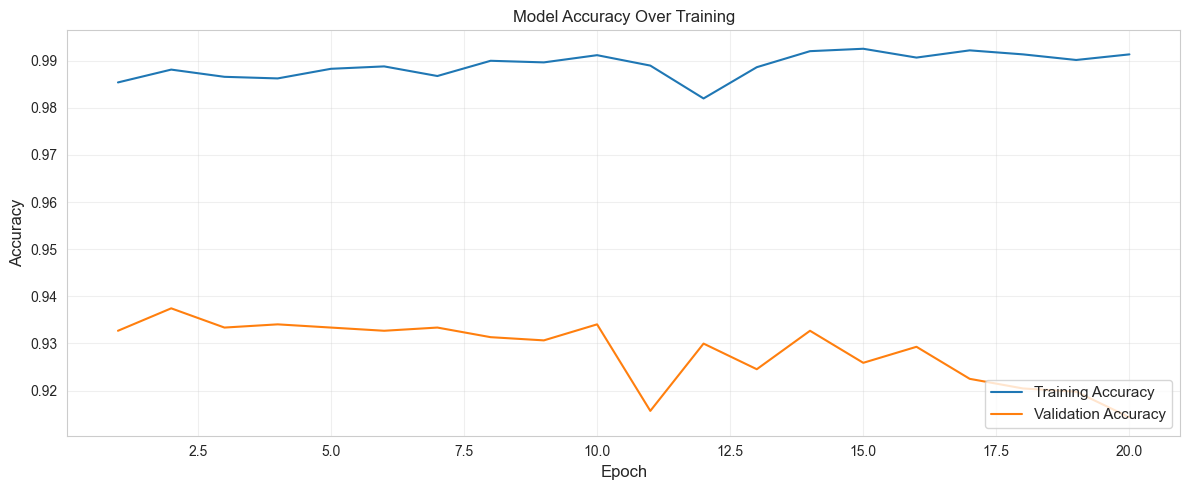

In [55]:
# TODO: Plot training accuracy vs validation accuracy over epochs
# Use best_history.history['accuracy'] and best_history.history['val_accuracy']

train_accuracy = best_history.history['accuracy']
val_accuracy = best_history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)

if best_history is not None:
    plt.figure(figsize=(12, 5))
    
    plt.plot(epochs, train_accuracy, label='Training Accuracy')
    plt.plot(epochs, val_accuracy, label='Validation Accuracy')
    plt.title('Model Accuracy Over Training')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.show()
else:
    print("Train best model first to visualize results")

### Visualize Training Progress - Loss

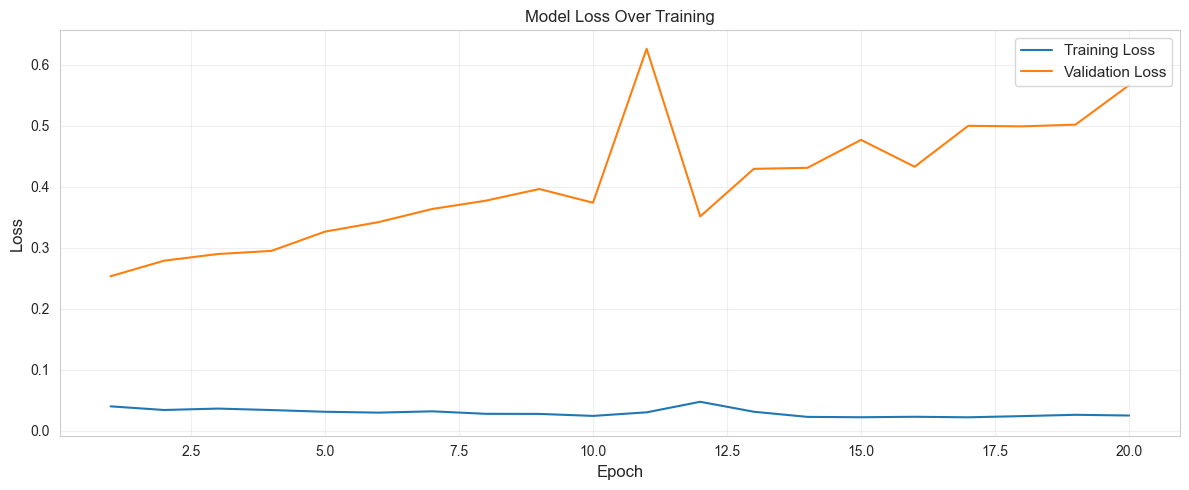

In [56]:
# TODO: Plot training loss vs validation loss over epochs
# Use best_history.history['loss'] and best_history.history['val_loss']

train_loss = best_history.history['loss']
val_loss = best_history.history['val_loss']

if best_history is not None:
    plt.figure(figsize=(12, 5))
    
    plt.plot(epochs, train_loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Model Loss Over Training')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.show()
else:
    print("Train best model first to visualize results")

---
## Step 6: Compare Against Unit 7 PCA + Random Forest

In [57]:
# TODO: Enter your Unit 7 PCA+Random Forest results here
# You should have recorded these in Unit 7
unit7_pca_accuracy = .365117
unit7_pca_time = .26

unit7_rf_accuracy = .926026
unit7_rf_time = 10.10

# Create comparison table
comparison = pd.DataFrame({
    'Model': [
        'Baseline NN (1 layer, 64 nodes)',
        'Best Model (Narrow)',
        'Unit 7: PCA',
        'Unit 7: Random Forest'
    ],
    'Features/Layers': [
        '1 hidden layer',
        '2 hidden layers, 32 nodes each',
        '26 PCA components',
        '562 components'
    ],
    'Test Accuracy': [
        baseline_test_accuracy,
        best_test_accuracy,
        unit7_pca_accuracy,
        unit7_rf_accuracy
    ],
    'Training Time': [
        f"{baseline_time:.2f}s" if baseline_time else 'N/A',
        f"{best_time:.2f}s" if best_time else 'N/A',
        f"{unit7_pca_time:.2f}s" if unit7_pca_time else 'N/A',
        f"{unit7_rf_time:.2f}s" if unit7_rf_time else 'N/A'
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)


MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7
                          Model                Features/Layers  Test Accuracy Training Time
Baseline NN (1 layer, 64 nodes)                 1 hidden layer       0.930098        13.76s
            Best Model (Narrow) 2 hidden layers, 32 nodes each       0.895826        13.03s
                    Unit 7: PCA              26 PCA components       0.365117         0.26s
          Unit 7: Random Forest                 562 components       0.926026        10.10s


### Reflection on Neural Network vs PCA+Random Forest
In the Markdown cell, write 2-3 sentences that answer the following questions:
- How does your best neural network compare to PCA+Random Forest?
- Did the neural network's ability to learn its own features from raw sensor data lead to better performance than manually engineering features with PCA? (2-3 sentences)

The best neural network is right on par with the random forest when it comes to accuracy and are generally similar in training time. PCA outperforms the neural network and random forest by a large factor but comes nowhere close with accuracy. The neural network's unsuperivsed outline worked much better than the manual process that PCA had which can be reflected by the accuracy numbers.

---
## Step 7: Reflect on When to Use Neural Networks

### When to Use Neural Networks vs Simpler Models

In the Markdown cell below, write 3-4 sentences addressing the following: 
- Based on your results and what you learned in the resources, when should you use neural networks versus simpler models like random forests? Consider factors like data type (sensor data, images, text vs tabular business data), dataset size, interpretability needs, and performance requirements. 
- Give at least one example of when you'd choose neural networks and one example of when you'd choose random forests

Neural networks are best for data that can be analyzed in an unsupervised manner such as images or sensor data. For the added complexity and training time, it must be a very large data set. If it is a smaller set, then the justification falls short for using the neural network frame because a random forest can handle that with no issues and similar accuracy. A neural network would be used on images in large quantities so the unsupervised framework can thrive. For a random forest, a smaller dataset with tabular information would be ideal for the feature engineering and supervised side of it.

---
## Step 8: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline neural network trained and evaluated
   - At least 3 depth experiments (1, 2, 3 layers)
   - At least 3 width experiments (32, 64, 128 nodes)
   - Best model trained for 30 epochs with accuracy and loss plots
   - Comparison table with baseline NN, best NN, and Unit 7 PCA+RF
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed neural networks assignment'
git push
```

Submit your GitHub repository link on the course platform.